##Parâmetros da Simulação

In [1]:
import os

os.environ.setdefault("NUMBA_DISABLE_COVERAGE", "1")

import numpy as np

from numba import jit

import time

from tqdm.notebook import tqdm

K = 512  # tamanho da chave
L = 412  # tamanho da tag e da mensagem
N = 10**3
rho_s = np.sqrt(0.985)  # alocação de potência para a mensagem
snr_db = 10  # relação SNR em dB
eta = 1e-7  # tolerância de falso negativo máxima

SNR_LINEAR = 10 ** (snr_db / 10)
SIGMA2W_BASE = 1.0 / SNR_LINEAR


# Mensagem e Modulação BPSK#


In [2]:
def modulator_bpsk(L, seed=None):
    """Modulação BPSK vetorizada."""
    if seed is not None:
        np.random.seed(seed)
    s_bin = np.random.randint(0, 2, size=L, dtype=np.int8)
    s_bpsk = 1 - 2 * s_bin
    return s_bin, s_bpsk


#Geração das TAGs


In [3]:
A, B, C = 6, 1, 1

def Mfunc_fast(x, K):
    return (A * x**2 + B * x + C) % (1 << K)


@jit(nopython=True)
def orbit_fast(x0, steps, beta=1e-6):
    xorbit = np.empty(steps, dtype=np.float64)
    x = x0
    inv_beta_plus = 2.0 / (beta + 1)
    inv_beta_minus = 2.0 / (beta - 1)
    const_plus = (1 - beta) / (beta + 1)
    const_minus = -(beta + 1) / (beta - 1)
    for i in range(steps):
        if x < beta:
            x = inv_beta_plus * x + const_plus
        else:
            x = inv_beta_minus * x + const_minus
        xorbit[i] = x
    return xorbit


def binary_to_int_fast(binary_array):
    value = 0
    for bit in binary_array.tolist():
        value = (value << 1) | int(bit)
    return value


def generate_tag(L, K, bits_msg, chave, x0=None):
    sigma = K - L
    if x0 is None:
        m_filled = np.resize(bits_msg, K)
        s_xor_k = np.bitwise_xor(m_filled, chave)
        xor_value = binary_to_int_fast(s_xor_k)
        xi = Mfunc_fast(xor_value, K=K)
        x0_norm = (xi / (2 ** K - 1)) * 2 - 1
    else:
        x0_norm = float(np.clip(x0, -1.0, 1.0))
    orb = orbit_fast(x0_norm, K)
    return orb[sigma:]


In [4]:
chave = np.random.randint(0, 2, K, dtype=np.int8)
bits_msg, bpsk_msg = modulator_bpsk(L)
tag_legit = generate_tag(L, K, bits_msg, chave)
x0_fake = np.random.uniform(-1.0, 1.0)
tag_fake = generate_tag(L, K, bits_msg, chave, x0=x0_fake)

_ = generate_tag(L, K, bits_msg, chave)
start = time.time()
for _ in range(100):
    _ = generate_tag(L, K, bits_msg, chave)
elapsed_ms = (time.time() - start) * 1000

print(f"Tempo para 100 tags legítimas: {elapsed_ms:.2f} ms")
print(f"Média legit: {np.mean(tag_legit):.6f}")
print(f"Variância legit: {np.var(tag_legit):.6f}")
print(f"Potência legit: {np.mean(tag_legit**2):.6f}")
print(f"Média fake: {np.mean(tag_fake):.6f}")
print(f"Variância fake: {np.var(tag_fake):.6f}")
print(f"Potência fake: {np.mean(tag_fake**2):.6f}")
print(f"Correlação legit x fake: {np.sum(tag_legit * tag_fake):.6f}")


Tempo para 100 tags legítimas: 14.41 ms
Média legit: 0.005576
Variância legit: 0.330680
Potência legit: 0.330711
Média fake: 0.016335
Variância fake: 0.324681
Potência fake: 0.324948
Correlação legit x fake: -5.301576


In [5]:
# Garantir que funcoes de transmissao existam antes do uso
try:
    combine_message_tag
except NameError:
    @jit(nopython=True)
    def compute_tag_power_fast(tag):
        return np.mean(tag**2)
    def combine_message_tag(s, tag, rho_s):
        Ptag = compute_tag_power_fast(tag)
        rho_t = np.sqrt((1 - rho_s**2) / Ptag)
        return rho_s * s + rho_t * tag, rho_t

x_legit, rho_t_legit = combine_message_tag(bpsk_msg, tag_legit, rho_s)
x_fake, rho_t_fake = combine_message_tag(bpsk_msg, tag_fake, rho_s)
print(f"Ganho rho_t legítimo: {rho_t_legit:.6f}")
print(f"Ganho rho_t falso: {rho_t_fake:.6f}")
print(f"Energia sinal legítimo: {np.mean(x_legit**2):.6f}")
print(f"Energia sinal falso: {np.mean(x_fake**2):.6f}")


Ganho rho_t legítimo: 0.212972
Ganho rho_t falso: 0.214852
Energia sinal legítimo: 0.999595
Energia sinal falso: 1.012753


#Transmissão#


In [6]:
@jit(nopython=True)
def compute_tag_power_fast(tag):
    return np.mean(tag**2)


def combine_message_tag(s, tag, rho_s):
    Ptag = compute_tag_power_fast(tag)
    rho_t = np.sqrt((1 - rho_s**2) / Ptag)
    x = rho_s * s + rho_t * tag
    return x, rho_t


def gen_noise_fast(snr_db, length):
    sigma2w = SIGMA2W_BASE
    noise = np.random.normal(0, np.sqrt(sigma2w), length)
    return sigma2w, noise


def add_awgn(x, snr_db):
    sigma2w, noise = gen_noise_fast(snr_db, len(x))
    y = x + noise
    return y, noise


##Recepção

In [7]:
@jit(nopython=True)
def detect_tag_fast(y, s, t_ref, rho_s, rho_t):
    stat = 0.0
    for i in range(len(y)):
        y_minus_msg = (y[i] - rho_s * s[i]) / rho_t
        stat += y_minus_msg * t_ref[i]
    return stat


# Limiar de decisão e Matriz de Confusão

In [8]:
from math import erfc
from scipy.stats import norm


def Qfunc_fast(x):
    return 0.5 * erfc(x / np.sqrt(2))


def thresh_optimized(std_dev, mean, alpha):
    return norm.ppf(1 - alpha, loc=mean, scale=std_dev)


@jit(nopython=True)
def tauVarCalc_fast(sigma2w, length, rho_t, sigma2tag):
    return (sigma2tag * sigma2w * length) / (rho_t**2)


def threshold_decision(sigma2w, length, rho_t, tag, eta, mu=0.0):
    sigma2tag = np.var(tag)
    sigma2_v = tauVarCalc_fast(sigma2w, length, rho_t, sigma2tag)
    return thresh_optimized(np.sqrt(sigma2_v), mu, eta)


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def compute_confusion_matrix(stat_H1, stat_H0, tau):
    y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
    y_scores = np.concatenate([stat_H1, stat_H0])
    if np.isscalar(tau):
        tau_vec = np.full_like(y_scores, tau, dtype=float)
    else:
        tau_vec = np.array([tau[i % len(tau)] for i in range(len(y_scores))])
    y_pred = (y_scores >= tau_vec).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    cm_normalized = cm.astype(float) / len(stat_H0)
    print(f"TP: {TP/len(stat_H1):.3f}, FP: {FP/len(stat_H0):.3f}, TN: {TN/len(stat_H0):.3f}, FN: {FN/len(stat_H1):.3f}")
    print(f"Accuracy: {(TP + TN) / len(y_true):.3f}")
    print(f"False Positive Rate: {FP/len(stat_H0):.3f}")
    print(f"False Negative Rate: {FN/len(stat_H1):.3f}")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['H0', 'H1'])
    disp.plot(cmap='Blues')
    plt.grid(False)
    plt.title('Matriz de Confusão')
    plt.show()


/home/matheus/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/matheus/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#Teste de Hipótese

In [10]:
def simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave, sigma2w, eta):
    all_stat_H1 = np.zeros(N, dtype=np.float64)
    all_stat_H0 = np.zeros(N, dtype=np.float64)
    tau_vec = np.zeros(N, dtype=np.float64)
    for n in range(N):
        bits_msg, bpsk_msg = modulator_bpsk(L)
        tag_legit = generate_tag(L, K, bits_msg, chave)
        x_legit, rho_t_legit = combine_message_tag(bpsk_msg, tag_legit, rho_s)
        y_legit, _ = add_awgn(x_legit, snr_db)
        tau_H1 = detect_tag_fast(y_legit, bpsk_msg, tag_legit, rho_s, rho_t_legit)
        x0_fake = np.random.uniform(-1.0, 1.0)
        tag_fake = generate_tag(L, K, bits_msg, chave, x0=x0_fake)
        x_fake = rho_s * bpsk_msg + rho_t_legit * tag_fake
        y_fake, _ = add_awgn(x_fake, snr_db)
        tau_H0 = detect_tag_fast(y_fake, bpsk_msg, tag_legit, rho_s, rho_t_legit)
        tau_vec[n] = threshold_decision(sigma2w, L, rho_t_legit, tag_legit, eta)
        all_stat_H1[n] = tau_H1
        all_stat_H0[n] = tau_H0
    return all_stat_H1, all_stat_H0, tau_vec


##Simulação

#Segunda opcao de threshold (empírico e otimizado)



In [11]:
def find_threshold_to_reduce_fp(stat_H1, stat_H0, eta):
    stat_H0_sorted = np.sort(stat_H0)
    all_scores = np.sort(np.concatenate([stat_H1, stat_H0]))
    fp_counts = stat_H0_sorted.size - np.searchsorted(stat_H0_sorted, all_scores, side='left')
    fp_rates = fp_counts / stat_H0_sorted.size
    valid_idx = np.where(fp_rates <= eta)[0]
    if len(valid_idx) == 0:
        return None
    return all_scores[valid_idx[0]]


##Histogramas

In [12]:
sigma2w_default = SIGMA2W_BASE
print(f"Variância base do ruído: {sigma2w_default:.3e}")


Variância base do ruído: 1.000e-01


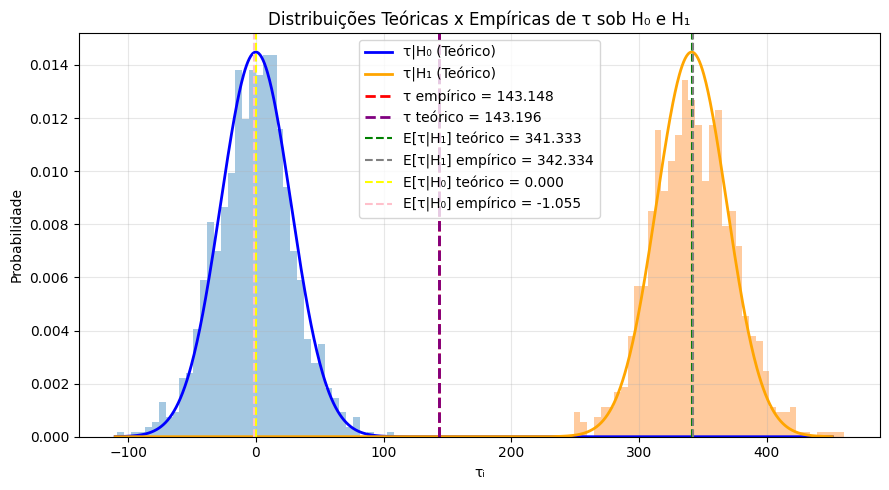

In [13]:
def plot_hist_teorico_empirico(K, L, N, snr_db, eta, rho_s):
    rho_t = np.sqrt((1 - rho_s**2) * 3)
    SNR = 10 ** (snr_db / 10)
    sigma2tag = 1 / 3
    sigma2v = (sigma2tag * L) / (SNR * rho_t**2)
    tau_teorico = thresh_optimized(np.sqrt(sigma2v), 0.0, eta)
    mu_H0 = 0.0
    mu_H1 = L / 3
    min_val = min(mu_H0 - 4 * np.sqrt(sigma2v), mu_H1 - 4 * np.sqrt(sigma2v))
    max_val = max(mu_H0 + 4 * np.sqrt(sigma2v), mu_H1 + 4 * np.sqrt(sigma2v))
    x = np.linspace(min_val, max_val, N)
    pdf_H0 = norm.pdf(x, loc=mu_H0, scale=np.sqrt(sigma2v))
    pdf_H1 = norm.pdf(x, loc=mu_H1, scale=np.sqrt(sigma2v))
    chave = np.random.randint(0, 2, K, dtype=np.int8)
    sigma2w, _ = gen_noise_fast(snr_db, L)
    stat_H1, stat_H0, threshold = simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave, sigma2w, eta)
    plt.figure(figsize=(9, 5))
    plt.hist(stat_H0, bins=40, density=True, alpha=0.4, color='tab:blue')
    plt.hist(stat_H1, bins=40, density=True, alpha=0.4, color='tab:orange')
    plt.plot(x, pdf_H0, color='blue', linewidth=2, label='τ|H₀ (Teórico)')
    plt.plot(x, pdf_H1, color='orange', linewidth=2, label='τ|H₁ (Teórico)')
    plt.axvline(np.mean(threshold), color='red', linestyle='--', linewidth=2, label=f'τ empírico = {np.mean(threshold):.3f}')
    plt.axvline(tau_teorico, color='purple', linestyle='--', linewidth=2, label=f'τ teórico = {tau_teorico:.3f}')
    plt.axvline(mu_H1, color='green', linestyle='--', linewidth=1.5, label=f'E[τ|H₁] teórico = {mu_H1:.3f}')
    plt.axvline(np.mean(stat_H1), color='grey', linestyle='--', linewidth=1.5, label=f'E[τ|H₁] empírico = {np.mean(stat_H1):.3f}')
    plt.axvline(mu_H0, color='yellow', linestyle='--', linewidth=1.5, label=f'E[τ|H₀] teórico = {mu_H0:.3f}')
    plt.axvline(np.mean(stat_H0), color='pink', linestyle='--', linewidth=1.5, label=f'E[τ|H₀] empírico = {np.mean(stat_H0):.3f}')
    plt.title('Distribuições Teóricas x Empíricas de τ sob H₀ e H₁')
    plt.xlabel('τᵢ')
    plt.ylabel('Probabilidade')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_hist_teorico_empirico(1056, 1024, 1000, 10, eta, rho_s)


##Trade-offs

In [14]:
def fnr_vs_L_theoretical(K, N, snr_db, eta, rho_s):
    rho_t = np.sqrt((1 - rho_s**2) * 3)
    SNR = 10 ** (snr_db / 10)
    L_max = K
    L_values = range(32, L_max, 32)
    fnr_prob = []
    tau_H1 = np.zeros(N, dtype=np.float64)
    variancias = np.zeros(N, dtype=np.float64)
    for L in tqdm(L_values, desc='FNR Teórico'):
        prob = 0.0
        for _ in range(50):
            for n in range(N):
                chave = np.random.randint(0, 2, L + 32, dtype=np.int8)
                bits_msg, _ = modulator_bpsk(L)
                tag = generate_tag(L, L + 32, bits_msg, chave)
                tau_H1[n] = np.sum(tag**2)
                variancias[n] = np.var(tag)
            sigma2tag = np.mean(variancias)
            sigma2v = (sigma2tag * L) / (SNR * rho_t**2)
            tau = thresh_optimized(np.sqrt(sigma2v), 0.0, eta)
            prob += (1 - Qfunc_fast((tau - np.mean(tau_H1)) / np.sqrt(sigma2v))) / 50
        fnr_prob.append(prob)
    return fnr_prob


In [15]:
def fnr_vs_L_MonteCarlo(K, N, snr_db, eta, rho_s):
    L_max = K
    L_values = range(32, L_max, 32)
    fnr_values = []
    for L in tqdm(L_values, desc='FNR Monte Carlo'):
        fnr = 0.0
        for _ in range(50):
            chave = np.random.randint(0, 2, L + 32, dtype=np.int8)
            sigma2w, _ = gen_noise_fast(snr_db, L)
            stat_H1, stat_H0, thresh_vec = simulate_hypothesis_test(L, L + 32, N, rho_s, snr_db, chave, sigma2w, eta)
            y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
            y_scores = np.concatenate([stat_H1, stat_H0])
            tau_vec = np.array([thresh_vec[i % len(thresh_vec)] for i in range(len(y_scores))])
            y_pred = (y_scores >= tau_vec).astype(int)
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            TN, FP, FN, TP = cm.ravel()
            fnr += (FN / len(stat_H1)) / 50
        fnr_values.append(fnr)
    return fnr_values


In [16]:
start_time = time.time()
auth_prob = fnr_vs_L_theoretical(512, 10**3, snr_db, eta, rho_s)
np.savez('teorico_tagFalsa_0.npz', auth_prob=auth_prob)
print(f'Tempo teórico: {time.time() - start_time:.2f}s')


FNR Teórico:   0%|          | 0/15 [00:00<?, ?it/s]

Tempo teórico: 73.43s


In [17]:
start_time = time.time()
fnr_values = fnr_vs_L_MonteCarlo(512, 10**3, snr_db, eta, rho_s)
np.savez('fnr_MonteCarlo_tagFalsa.npz', fnr_values=fnr_values)
print(f'Tempo Monte Carlo: {time.time() - start_time:.2f}s')


FNR Monte Carlo:   0%|          | 0/15 [00:00<?, ?it/s]

Tempo Monte Carlo: 172.63s


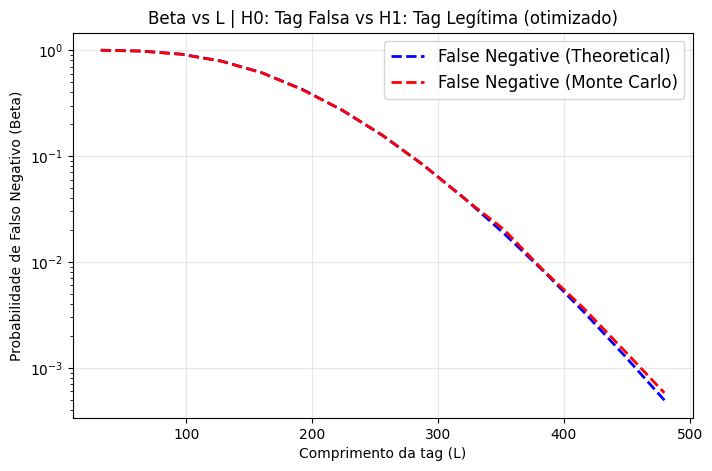

In [18]:
L_values = range(32, 512, 32)
auth_prob = np.load('teorico_tagFalsa_0.npz')['auth_prob']
fnr_values = np.load('fnr_MonteCarlo_tagFalsa.npz')['fnr_values']
plt.figure(figsize=(8, 5))
plt.semilogy(L_values, auth_prob, '--b', linewidth=2, label='False Negative (Theoretical)')
plt.semilogy(L_values, fnr_values, '--r', linewidth=2, label='False Negative (Monte Carlo)')
plt.xlabel('Comprimento da tag (L)')
plt.ylabel('Probabilidade de Falso Negativo (Beta)')
plt.title('Beta vs L | H0: Tag Falsa vs H1: Tag Legítima (otimizado)')
plt.legend(loc='best', fontsize=12, frameon=True)
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
"""# ====== Plot ======

 """

'# ====== Plot ======\n\n '